# 1. Data Source Identification and Project Recap

## Project recap and analytical roadmap

This project uses the Home Credit Default Risk dataset to support credit-risk decision making for applicants who may have limited traditional credit history. The business problem is that Home Credit needs to reduce default losses while still approving profitable customers who can repay. The analytical workflow follows a CRISP-DM style structure:

1. **Business understanding**: frame the lending decision as a risk-return problem.
2. **Data understanding**: inspect the eight Home Credit tables, target imbalance, missingness, validity, consistency, and key predictors.
3. **Data preparation**: clean abnormal values, impute missing values, encode categorical variables, aggregate historical credit records, and select features.
4. **Predictive analytics**: build a baseline model in this notebook and a scorecard model in Notebook 02.
5. **Prescriptive analytics**: use calibrated default probabilities from Notebook 02 to optimise loan-capital allocation in Notebook 03.

The outputs of this notebook are therefore not only descriptive summaries; they also create the cleaned and feature-engineered data used by the predictive and prescriptive stages.

## 1.1 Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
application_train = pd.read_csv("dataset/application_train.csv", low_memory=False)
application_test = pd.read_csv("dataset/application_test.csv", low_memory=False)
bureau = pd.read_csv("dataset/bureau.csv", low_memory=False)
bureau_balance = pd.read_csv("dataset/bureau_balance.csv", low_memory=False)
credit_card_balance = pd.read_csv("dataset/credit_card_balance.csv", low_memory=False)
installments_payments = pd.read_csv("dataset/installments_payments.csv", low_memory=False)
pos_cash_balance = pd.read_csv("dataset/POS_CASH_balance.csv", low_memory=False)
previous_application = pd.read_csv("dataset/previous_application.csv", low_memory=False)

print("application_train:", application_train.shape)
print("application_test:", application_test.shape)
print("bureau:", bureau.shape)
print("bureau_balance:", bureau_balance.shape)
print("credit_card_balance:", credit_card_balance.shape)
print("installments_payments:", installments_payments.shape)
print("pos_cash_balance:", pos_cash_balance.shape)
print("previous_application:", previous_application.shape)

application_train: (307511, 122)
application_test: (48744, 121)
bureau: (1716428, 17)
bureau_balance: (27299925, 3)
credit_card_balance: (3840312, 23)
installments_payments: (13605401, 8)
pos_cash_balance: (10001358, 8)
previous_application: (1670214, 37)


In [3]:
# Reducing the memory usage, avoiding large file sizes.
def optimize_data(df):

    for col in df.columns:

        if df[col].dtype == "int64":
            df[col] = pd.to_numeric(df[col], downcast="integer")

        elif df[col].dtype == "float64":
            df[col] = pd.to_numeric(df[col], downcast="float")

    return df


# Optimize data types for each of the eight tables.
application_train = optimize_data(application_train)
application_test = optimize_data(application_test)
bureau = optimize_data(bureau)
bureau_balance = optimize_data(bureau_balance)
credit_card_balance = optimize_data(credit_card_balance)
installments_payments = optimize_data(installments_payments)
pos_cash_balance = optimize_data(pos_cash_balance)
previous_application = optimize_data(previous_application)

print("All 8 tables have been optimize!")

All 8 tables have been optimize!


### Data inventory and relevance

The project uses eight linked Home Credit tables. The main table `application_train.csv` contains the target variable and applicant-level information. The remaining historical tables enrich the main table with external bureau records, monthly bureau status, previous Home Credit applications, POS/cash balances, credit-card balances, and instalment payment behaviour. This follows the Topic 3 data-source standard: each table is treated as a distinct source with a clear role in the business problem.

| Data source | Business role in the project |
|---|---|
| `application_train/test` | Main loan application profile and target/default label |
| `bureau` and `bureau_balance` | External credit history and delinquency behaviour |
| `previous_application` | Prior Home Credit application decisions and outcomes |
| `POS_CASH_balance` | Historical POS/cash loan balance behaviour |
| `credit_card_balance` | Historical credit-card utilisation and repayment behaviour |
| `installments_payments` | Actual instalment payment timing and amount behaviour |
| `HomeCredit_columns_description` | Field definitions for interpretation and documentation |

## 1.2 Target Distribution

In [4]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
target_counts = application_train["TARGET"].value_counts()
target_pct = (target_counts / len(application_train) * 100).round(2)
print("TARGET value_counts:", target_counts)
print("TARGET Percentage:", target_pct)
default_rate = application_train["TARGET"].mean().round(4)
print("Default Rate:", default_rate)

TARGET value_counts: TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET Percentage: TARGET
0    91.93
1     8.07
Name: count, dtype: float64
Default Rate: 0.0807


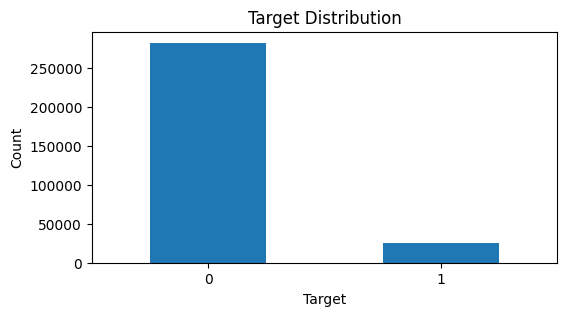

In [6]:
plt.figure(figsize=(6, 3))
application_train['TARGET'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Target')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()

**Business interpretation.** The target distribution shows a highly imbalanced credit-risk problem: default customers are a small minority compared with non-default customers. This matters because a model can appear accurate by predicting most customers as non-default, while still failing to identify risky applicants. For this reason, later models use metrics such as ROC-AUC and KS rather than relying only on accuracy.

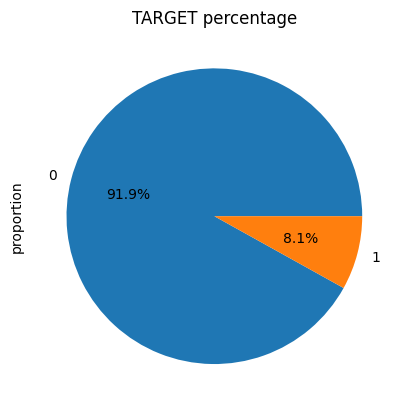

In [7]:
target_pct = application_train["TARGET"].value_counts(normalize=True)
target_pct = target_pct.sort_index()
plt.figure()
target_pct.plot(kind="pie",autopct="%1.1f%%")
plt.title("TARGET percentage")
plt.show()

# 2. Data Quality Assessment

## 2.1 Completeness

In [8]:
# Missing Value
missing = application_train.isna().sum()
missing_pct = (missing / len(application_train) * 100).round(2)
missing_df = pd.DataFrame({"Missing Value": missing, "Missing Percentage(%)": missing_pct})
missing_df = missing_df[missing_df["Missing Value"] > 0].sort_values("Missing Percentage(%)", ascending=False)
print("Number of column with Missing Value:", len(missing_df))
missing_df.head(20)

Number of column with Missing Value: 67


,Missing Value,Missing Percentage(%)
COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_MODE,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_AVG,210199,68.35


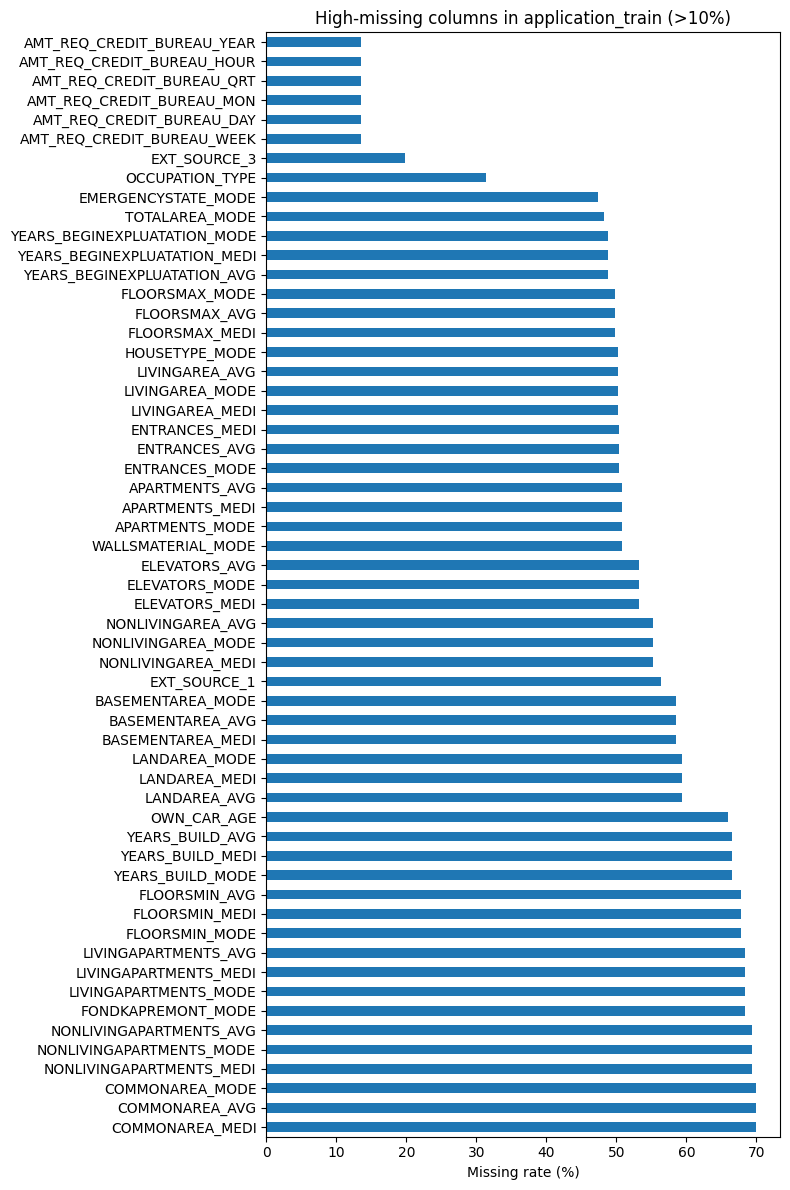

In [9]:
import matplotlib.pyplot as plt

high_missing = missing_df.loc[missing_df["Missing Percentage(%)"] > 10, "Missing Percentage(%)"]
high_missing.plot.barh(figsize=(8, min(12, len(high_missing) * 0.4)))
plt.title("High-missing columns in application_train (>10%)")
plt.xlabel("Missing rate (%)")
plt.tight_layout()
plt.show()

**Business interpretation.** Many housing and building-related variables have high missingness. In a consumer-finance context, missingness may itself contain information about applicant documentation quality or data availability, but excessive missingness can also weaken model reliability. Therefore the project documents missingness, imputes consistently, and later removes or controls low-value/high-correlation features.

## 2.2 Accuracy

In [10]:
# Duplicate check on primary key
dup_sk_id = application_train["SK_ID_CURR"].duplicated().sum()
print("Duplicate SK_ID_CURR:", dup_sk_id)

dup_rows = application_train.duplicated().sum()
print("Fully duplicated rows:", dup_rows)

Duplicate SK_ID_CURR: 0
Fully duplicated rows: 0


## 2.3 Consistency

### 2.3.1 Check the format of missing value in "NAME_FAMILY_STATUS"

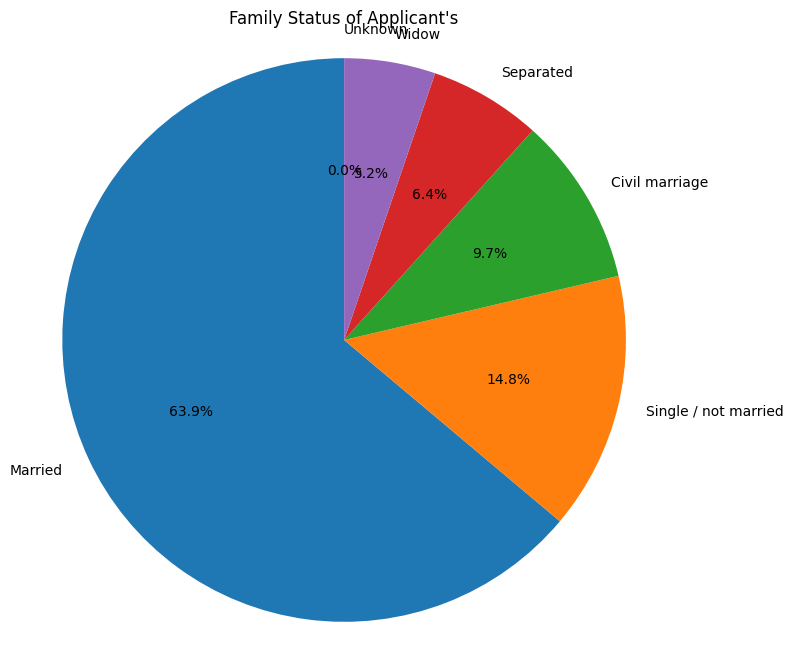

In [11]:
temp = application_train["NAME_FAMILY_STATUS"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(temp.values, labels=temp.index, autopct="%1.1f%%", startangle=90)
plt.title("Family Status of Applicant's")
plt.axis("equal")
plt.show()

In [12]:
# Check unknown percentage
unknown_count = application_train["NAME_FAMILY_STATUS"].value_counts()["Unknown"]
total_count = application_train["NAME_FAMILY_STATUS"].value_counts().sum()
unknown_percentage = (unknown_count / total_count) * 100
print("Unknown Percentage", round(unknown_percentage, 2), "%")

# Count the number of "Unknown"
unknown_count = application_train["NAME_FAMILY_STATUS"].value_counts()["Unknown"]
print("Unknown Count:", unknown_count)

Unknown Percentage 0.0 %
Unknown Count: 2


### 2.3.2 Check the format of missing value in "ORGANIZATION_TYPE"

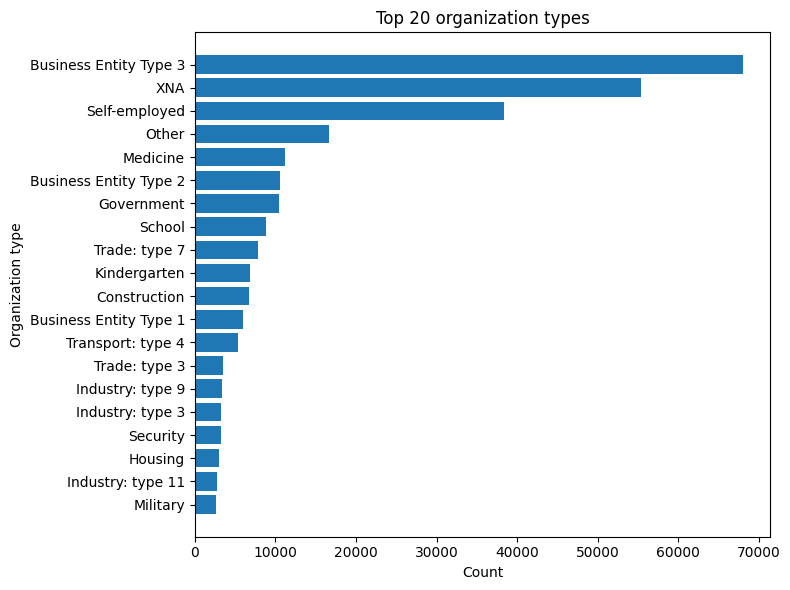

In [13]:
vc = application_train["ORGANIZATION_TYPE"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(8, 6))
labels = vc.index.astype(str)
values = vc.values
labels = labels[::-1]
values = values[::-1]
ax.barh(labels, values)
ax.set_xlabel("Count")
ax.set_ylabel("Organization type")
ax.set_title("Top 20 organization types")
plt.tight_layout()
plt.show()

In [14]:
# Count the number of "XNA" in "ORGANIZATION_TYPE".
unknown_count = application_train["ORGANIZATION_TYPE"].value_counts()["XNA"]
print("XNA Count", unknown_count)

# Calculate the XNA Percentage in "ORGANIZATION_TYPE".
unknown_percentage = (unknown_count / total_count) * 100
print("XNA Percentage", round(unknown_percentage,2),"%")

XNA Count 55374
XNA Percentage 18.01 %


In [15]:
# Using hypothesis test to examine whether there is a significant difference in default rates between "XNA" and "non-XNA" in the "ORGANIZATION_TYPE".
from scipy.stats import ttest_ind

# Separate "XNA" and "non-XNA"
xna_target = application_train[application_train["ORGANIZATION_TYPE"] == "XNA"]["TARGET"]
non_xna_target = application_train[application_train["ORGANIZATION_TYPE"] != "XNA"]["TARGET"]

# T-Test
t_stat, p_value = ttest_ind(xna_target, non_xna_target)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.6g}")

# Result Analytic
if p_value < 0.05:
    print("There is a significant difference in default rates between XNA and non-XNA.")
else:
    print("There is not a significant difference in default rates between XNA and non-XNA.")

t-statistic: -25.5284, p-value: 1.34653e-143
There is a significant difference in default rates between XNA and non-XNA.


###  2.3.3 Check the format of missing value in "CODE_GENDER"

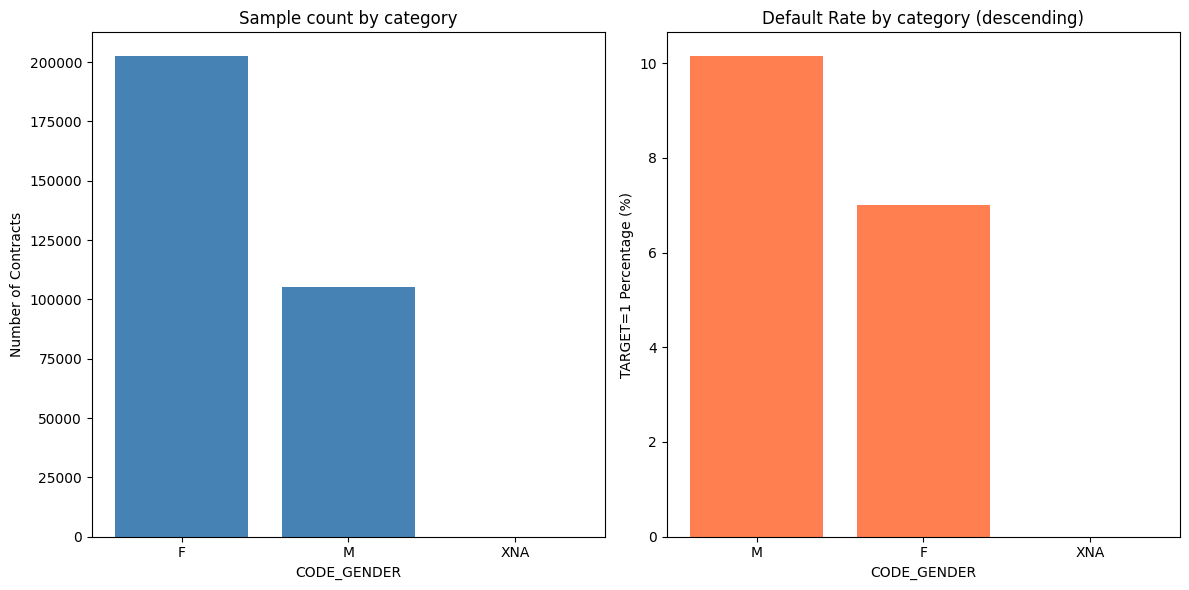

In [ ]:
feature = "CODE_GENDER"

temp = application_train[feature].value_counts()
df1 = pd.DataFrame({feature: temp.index, "Number of Contracts": temp.values})

cat_perc = (
    application_train[[feature, "TARGET"]]
    .groupby(feature, as_index=False)
    .mean()
    .sort_values("TARGET", ascending=False)
)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

ax1.bar(df1[feature].astype(str), df1["Number of Contracts"], color="steelblue")
ax1.set_xlabel(feature)
ax1.set_ylabel("Number of Contracts")
ax1.set_title("Sample count by category")

ax2.bar(cat_perc[feature].astype(str), cat_perc["TARGET"] * 100, color="coral")
ax2.set_xlabel(feature)
ax2.set_ylabel("TARGET=1 Percentage (%)")
ax2.set_title("Default Rate by category (descending)")

plt.tight_layout()
plt.show()

In [17]:
# Count the XNA in "CODE_GENDER"
unknown_count = application_train["CODE_GENDER"].value_counts()["XNA"]
print("XNA Count", unknown_count)

# Calculate the XNA Percentage in "CODE_GENDER"
unknown_percentage = (unknown_count / total_count) * 100
print("XNA Percentage",round(unknown_percentage,2), "%")

XNA Count 4
XNA Percentage 0.0 %


### 2.3.4 Check the format of missing value in "DAYS_LAST_PHONE_CHANGE"

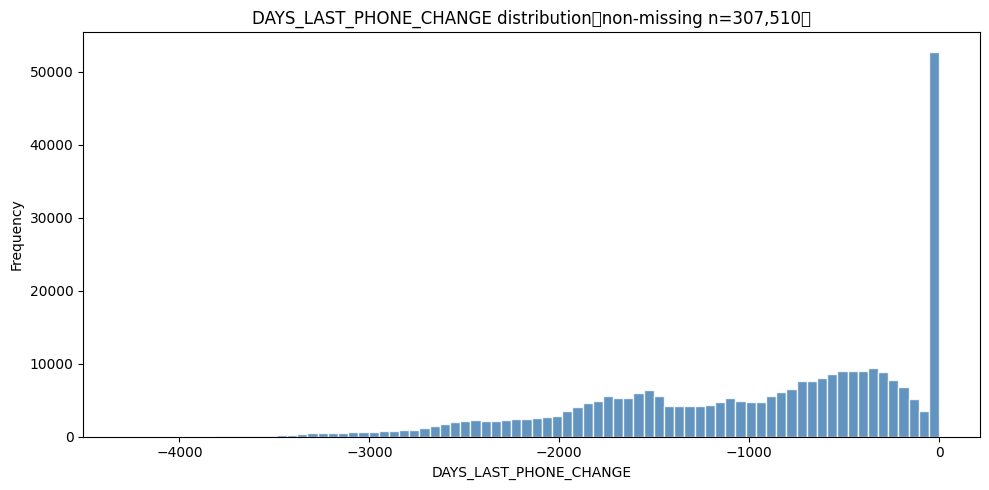

In [18]:
col = "DAYS_LAST_PHONE_CHANGE"
x = application_train[col].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(x, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(col)
ax.set_ylabel("Frequency")
ax.set_title(f"{col} distribution（non-missing n={len(x):,}）")
plt.tight_layout()
plt.show()


In [19]:
# Using hypothesis test to examine whether having DAYS_LAST_PHONE_CHANGE equal to 0 or not has a significant impact on the TARGET variable.
from statsmodels.stats.proportion import proportions_ztest

col, target = "DAYS_LAST_PHONE_CHANGE", "TARGET"
sub = application_train.dropna(subset=[col])
g0 = sub.loc[sub[col] == 0, target]
g1 = sub.loc[sub[col] != 0, target]

counts = np.array([g0.sum(), g1.sum()])
nobs = np.array([len(g0), len(g1)])

zstat, p = proportions_ztest(counts, nobs)
print("Z-test for two proportions")
print("Z =", round(zstat, 4))
print("p =", round(p, 6))

Z-test for two proportions
Z = 12.1093
p = 0.0


## 2.4 Validity

### 2.4.1 Check DAYS_BIRTH

In [20]:
# Check the age of application people. DAYS_BIRTH is negative value, representing the number of days before the application date.
display((application_train['DAYS_BIRTH'] / -365).describe())

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

### 2.4.2 Check DAYS_EMPLOYED

In [21]:
# Check the working days of application people. DAYS_EMPLOYED is negative value, representing the number of days before the application date.
application_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

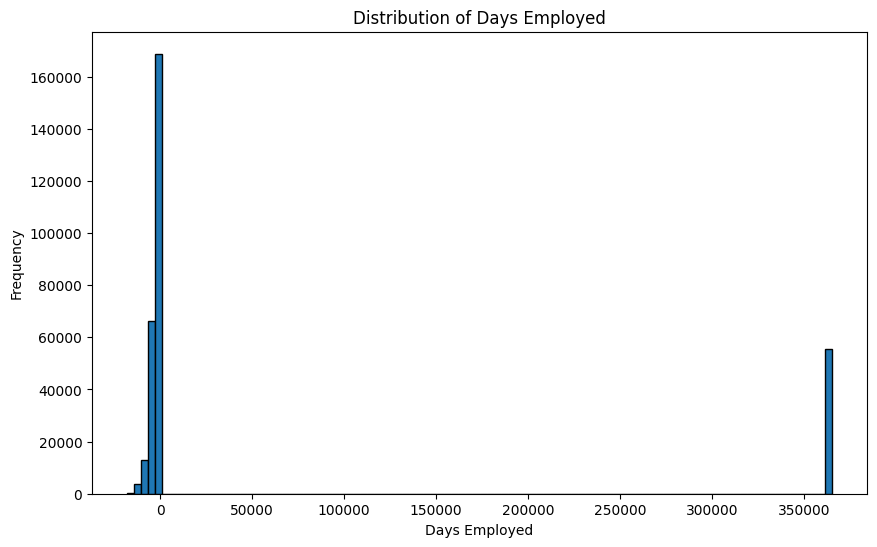

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(application_train['DAYS_EMPLOYED'], bins=100, edgecolor='black')
plt.title('Distribution of Days Employed')
plt.xlabel('Days Employed')
plt.ylabel('Frequency')
plt.show()

**Business interpretation.** `DAYS_EMPLOYED` contains the well-known Home Credit placeholder value `365243`, which represents an abnormal employment-duration code rather than a realistic employment history. This is important because employment stability is related to repayment ability. The project treats this value carefully during cleaning and feature engineering rather than interpreting it literally.

In [23]:
anom = application_train[application_train['DAYS_EMPLOYED'] == 365243]
non_anom = application_train[application_train['DAYS_EMPLOYED'] != 365243]
anom_rate = anom['TARGET'].mean()
non_anom_rate = non_anom['TARGET'].mean()
print("Default rate for non-outlier loans:", round(non_anom_rate * 100, 2), "%")
print("Default rate for outlier loans:", round(anom_rate * 100, 2), "%")
print("Total number of outliers in DAYS_EMPLOYED:", len(anom))

Default rate for non-outlier loans: 8.66 %
Default rate for outlier loans: 5.4 %
Total number of outliers in DAYS_EMPLOYED: 55374


In [24]:
# Test of above results
from scipy.stats import ttest_ind

anom_target = anom['TARGET']
non_anom_target = non_anom['TARGET']
t_stat, p_value = ttest_ind(anom_target, non_anom_target)
print("t-statistic",round(t_stat,6))
print("p-value",round(p_value,6))

if p_value < 0.05:
    print("There is a significant difference in default rates between outlier and non-outlier samples.")
else:
    print("There is not a significant difference in default rates between outlier and non-outlier samples")

t-statistic -25.52845
p-value 0.0
There is a significant difference in default rates between outlier and non-outlier samples.


### 2.4.3 Data validity checks for selected variables.

In [25]:
check_income = (application_train["AMT_INCOME_TOTAL"] <= 0).sum()
check_credit = (application_train["AMT_CREDIT"] <= 0).sum()
check_annuity = (application_train["AMT_ANNUITY"] < 0).sum()
check_target = application_train["TARGET"].isna().sum()

validity_summary = pd.DataFrame({
    "Check": [
        "AMT_INCOME_TOTAL <= 0",
        "AMT_CREDIT <= 0",
        "AMT_ANNUITY < 0",
        "TARGET missing"
    ],
    "Count": [
        check_income,
        check_credit,
        check_annuity,
        check_target
    ]
})
validity_summary

,Check,Count
0,AMT_INCOME_TOTAL <= 0,0
1,AMT_CREDIT <= 0,0
2,AMT_ANNUITY < 0,0
3,TARGET missing,0


# 3. Initial Data Wrangling

## 3.1 Handling Missing Value

### 3.1.1 Handling missing values in the main dataset

In [26]:
def application_cleaning(df, fill_missing=False, fill_value=0):

    df['CODE_GENDER'].replace('XNA', np.nan, inplace=True)
    df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
    df['DAYS_LAST_PHONE_CHANGE'].replace(0, np.nan, inplace=True)
    df['NAME_FAMILY_STATUS'].replace('Unknown', np.nan, inplace=True)
    df['ORGANIZATION_TYPE'].replace('XNA', np.nan, inplace=True)

    if fill_missing:
        df.fillna(fill_value, inplace=True)

    return df

In [27]:
application_train = application_cleaning(application_train.copy(),fill_missing=True)
application_test = application_cleaning(application_test.copy(),fill_missing=True)

In [28]:
print(application_train.isna().any().any())
print(application_test.isna().any().any())

False
False


### 3.1.2 Handling missing values in the other datasets

In [29]:
# bureau dataset
def bureau_cleaning(df, fill_missing=False, fill_value=0):

    df["DAYS_CREDIT_ENDDATE"] = df["DAYS_CREDIT_ENDDATE"].replace(365243, np.nan)
    df["DAYS_ENDDATE_FACT"] = df["DAYS_ENDDATE_FACT"].replace(365243, np.nan)
    df["DAYS_CREDIT_UPDATE"] = df["DAYS_CREDIT_UPDATE"].replace(365243, np.nan)

    if fill_missing:
        df.fillna(fill_value, inplace=True)

    return df


# bureau_balance dataset
def bureau_balance_cleaning(df, fill_missing=False, fill_value=0):

    if fill_missing:
        df.fillna(fill_value, inplace=True)

    return df


# credit_card_balance dataset
def credit_card_balance_cleaning(df, fill_missing=False, fill_value=0):

    # less than 0 defined as missing value
    df["AMT_DRAWINGS_ATM_CURRENT"] = df["AMT_DRAWINGS_ATM_CURRENT"].where(
        df["AMT_DRAWINGS_ATM_CURRENT"] >= 0, np.nan
    )

    if fill_missing:
        df.fillna(fill_value, inplace=True)

    return df


# installments_payments dataset
def installments_payments_cleaning(df, fill_missing=False, fill_value=0):

    if fill_missing:
        df.fillna(fill_value, inplace=True)

    return df


# pos_cash_balance dataset
def pos_cash_balance_cleaning(df, fill_missing=False, fill_value=0):

    if fill_missing:
        df.fillna(fill_value, inplace=True)

    return df


# previous_application dataset
def previous_application_cleaning(df, fill_missing=False, fill_value=0):

    df["NAME_CONTRACT_TYPE"] = df["NAME_CONTRACT_TYPE"].replace("XNA", np.nan)

    df["DAYS_FIRST_DRAWING"] = df["DAYS_FIRST_DRAWING"].replace(365243, np.nan)
    df["DAYS_FIRST_DUE"] = df["DAYS_FIRST_DUE"].replace(365243, np.nan)
    df["DAYS_LAST_DUE_1ST_VERSION"] = df["DAYS_LAST_DUE_1ST_VERSION"].replace(365243, np.nan)
    df["DAYS_LAST_DUE"] = df["DAYS_LAST_DUE"].replace(365243, np.nan)
    df["DAYS_TERMINATION"] = df["DAYS_TERMINATION"].replace(365243, np.nan)

    if fill_missing:
        df.fillna(fill_value, inplace=True)

    return df


In [30]:
# Clean each dataset

bureau_clean = bureau_cleaning(bureau.copy(), fill_missing=True, fill_value=-1)
bureau_balance_clean = bureau_balance_cleaning(bureau_balance.copy(), fill_missing=True, fill_value=-1)
credit_card_balance_clean = credit_card_balance_cleaning(credit_card_balance.copy(), fill_missing=True, fill_value=-1)
installments_payments_clean = installments_payments_cleaning(installments_payments.copy(), fill_missing=True, fill_value=-1)
pos_cash_balance_clean = pos_cash_balance_cleaning(pos_cash_balance.copy(), fill_missing=True, fill_value=-1)
previous_application_clean = previous_application_cleaning(previous_application.copy(), fill_missing=True, fill_value=-1)

In [31]:
# Check results

bureau_missing_cols = (bureau_clean.isna().sum() > 0).sum()
print("bureau missing columns:", bureau_missing_cols)

bureau_balance_missing_cols = (bureau_balance_clean.isna().sum() > 0).sum()
print("bureau_balance missing columns:", bureau_balance_missing_cols)

credit_card_balance_missing_cols = (credit_card_balance_clean.isna().sum() > 0).sum()
print("credit_card_balance missing columns:", credit_card_balance_missing_cols)

installments_payments_missing_cols = (installments_payments_clean.isna().sum() > 0).sum()
print("installments_payments missing columns:", installments_payments_missing_cols)

pos_cash_balance_missing_cols = (pos_cash_balance_clean.isna().sum() > 0).sum()
print("pos_cash_balance missing columns:", pos_cash_balance_missing_cols)

previous_application_missing_cols = (previous_application_clean.isna().sum() > 0).sum()
print("previous_application missing columns:", previous_application_missing_cols)


bureau missing columns: 0
bureau_balance missing columns: 0
credit_card_balance missing columns: 0
installments_payments missing columns: 0
pos_cash_balance missing columns: 0
previous_application missing columns: 0


## 3.2 Establishing and evaluating the baseline（benchmark）

#### 3.2.1 Feature encoding for the application_test and application_train dataset

In [32]:
from sklearn.preprocessing import LabelEncoder

app_train_baseline = application_train.copy()
app_test_baseline = application_test.copy()

train_labels = app_train_baseline["TARGET"]

app_train_baseline = app_train_baseline.drop("TARGET", axis=1)

# label encode columns with only 2 categories
le_count = 0

for col in app_train_baseline.columns:
    if app_train_baseline[col].dtype == "object":
        if app_train_baseline[col].nunique() <= 2:
            le = LabelEncoder()
            le.fit(app_train_baseline[col].astype(str))
            app_train_baseline[col] = le.transform(app_train_baseline[col].astype(str))
            app_test_baseline[col] = le.transform(app_test_baseline[col].astype(str))
            le_count = le_count + 1

print("label encoded columns:", le_count)

label encoded columns: 3


In [33]:
app_train_baseline = pd.get_dummies(app_train_baseline, dtype=int)
app_test_baseline = pd.get_dummies(app_test_baseline, dtype=int)

print("train shape after get_dummies:", app_train_baseline.shape)
print("test shape after get_dummies:", app_test_baseline.shape)

train shape after get_dummies: (307511, 248)
test shape after get_dummies: (48744, 245)


In [34]:
app_test_baseline = app_test_baseline.reindex(columns=app_train_baseline.columns, fill_value=0)

app_train_baseline["TARGET"] = train_labels

print("final train shape:", app_train_baseline.shape)
print("final test shape:", app_test_baseline.shape)

final train shape: (307511, 249)
final test shape: (48744, 248)


#### 3.2.2 Benchmark model - Logistic regression

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [36]:
X = app_train_baseline.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = app_train_baseline['TARGET']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [37]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr.fit(X_scaled, y)
print('Logistic regression model training completed.')

Logistic regression model training completed.


In [38]:
# Cross-validated ROC-AUC (5-fold, stratified sampling)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("5-fold cross-validated ROC-AUC:")

scores_rounded = []
for s in cv_scores:
    scores_rounded.append(round(s, 4))
print("Each Fold", scores_rounded)

mean_score = round(cv_scores.mean(), 4)
std_score = round(cv_scores.std(), 4)
print("Mean", mean_score, "±", std_score)

5-fold cross-validated ROC-AUC:
Each Fold [np.float64(0.726), np.float64(0.7341), np.float64(0.7308), np.float64(0.7353), np.float64(0.7274)]
Mean 0.7307 ± 0.0036


In [39]:
y_pred_proba = lr.predict_proba(X_scaled)[:, 1]
y_pred = lr.predict(X_scaled)

print("Classification report (Training set)")
report = classification_report(y, y_pred, target_names=['Non-default(0)', 'Default(1)'])
print(report)

Classification report (Training set)
                precision    recall  f1-score   support

Non-default(0)       0.96      0.67      0.79    282686
    Default(1)       0.15      0.67      0.25     24825

      accuracy                           0.67    307511
     macro avg       0.56      0.67      0.52    307511
  weighted avg       0.89      0.67      0.75    307511



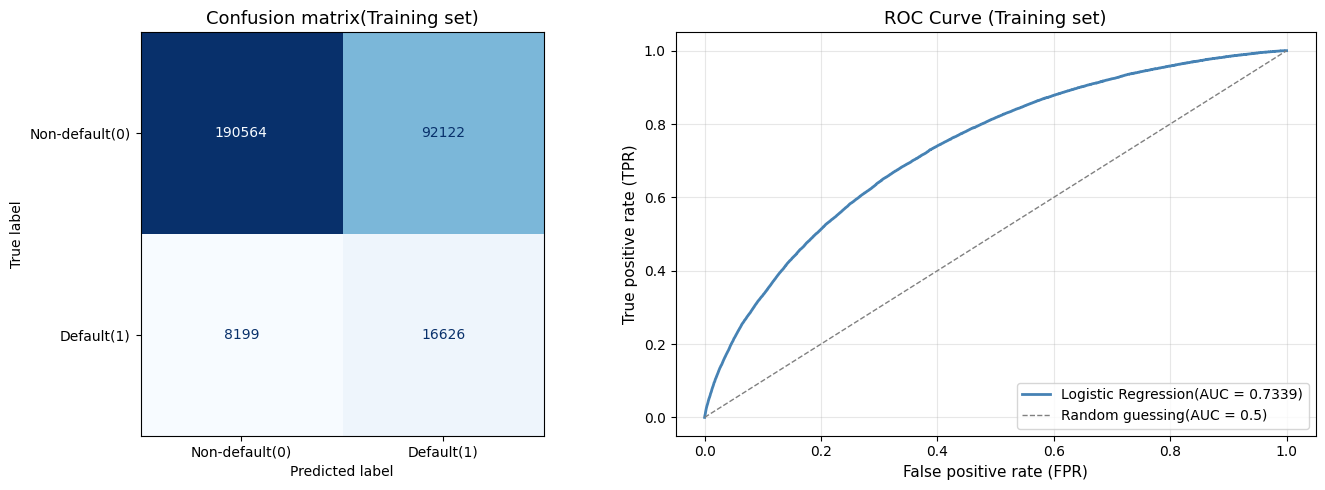

In [40]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-default(0)', 'Default(1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix(Training set)', fontsize=13)

# ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
auc_score = roc_auc_score(y, y_pred_proba)

label_text = "Logistic Regression(AUC = " + str(round(auc_score, 4)) + ")"
axes[1].plot(fpr, tpr,color='steelblue',linewidth=2,label=label_text)
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random guessing(AUC = 0.5)')
axes[1].set_xlabel('False positive rate (FPR)', fontsize=11)
axes[1].set_ylabel('True positive rate (TPR)', fontsize=11)
axes[1].set_title('ROC Curve (Training set)', fontsize=13)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
# KS statistic
ks_values = tpr - fpr
ks_score = ks_values.max()
ks_threshold = thresholds[ks_values.argmax()]

print("KS_score", round(ks_score, 4))
print("Threshold", round(ks_threshold, 4))

KS_score 0.3441
Threshold 0.4987


In [42]:
print("Baseline Logistic Regression(Training set) ROC-AUC:", round(auc_score, 4))
print("Baseline Logistic Regression(Training set) KS:", round(ks_score, 4))
print("Baseline Logistic Regression Mean of Cross-validated ROC-AUC:", mean_score, "±", std_score)

Baseline Logistic Regression(Training set) ROC-AUC: 0.7339
Baseline Logistic Regression(Training set) KS: 0.3441
Baseline Logistic Regression Mean of Cross-validated ROC-AUC: 0.7307 ± 0.0036


**Predictive analytics interpretation.** The baseline logistic regression provides a first benchmark before the final scorecard model. Its cross-validated ROC-AUC indicates that the application-level variables contain useful risk signal, but the model is still only a benchmark. Notebook 02 improves the modelling pipeline using WOE encoding, selected scorecard features, validation AUC, KS, and customer score mapping.

## 3.3 Feature engineering

#### 3.3.1 Create new features

In [43]:
def fe_application(df):

    df = df.copy()
    # DAYS_EMPLOYED to age ratio
    df["DAYS_EMPLOYED_PERC"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"].replace(0, np.nan)
    # Income-to-credit ratio(Debt burden)
    df["INCOME_CREDIT_PERC"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"].replace(0, np.nan)
    # Income per household member
    df["INCOME_PER_PERSON"]  = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"].replace(0, np.nan)
    # Annuity-to-income ratio
    df["ANNUITY_INCOME_PERC"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
    # Annuity-to-credit ratio(Debt repayment rate)
    df["PAYMENT_RATE"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"].replace(0, np.nan)
    # Credit-to-income ratio
    df["CREDIT_INCOME_PERCENT"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)

    new_cols = [
        "DAYS_EMPLOYED_PERC", "INCOME_CREDIT_PERC", "INCOME_PER_PERSON",
        "ANNUITY_INCOME_PERC", "PAYMENT_RATE", "CREDIT_INCOME_PERCENT",
    ]
    return df, new_cols


application_train, domain_feature_names = fe_application(application_train)
application_test, _ = fe_application(application_test)
print("New features added", domain_feature_names)
print("Number of application_train column", application_train.shape[1])
print("Number of application_test column", application_test.shape[1])

New features added ['DAYS_EMPLOYED_PERC', 'INCOME_CREDIT_PERC', 'INCOME_PER_PERSON', 'ANNUITY_INCOME_PERC', 'PAYMENT_RATE', 'CREDIT_INCOME_PERCENT']
Number of application_train column 128
Number of application_test column 127


#### 3.3.2 Create new features based on statistical methods

In [44]:
import gc

def agg_numeric(df, group_var, df_name):

    df = df.copy()
    for col in list(df.columns):
        if col != group_var and "SK_ID" in col:
            df = df.drop(columns=col)
    group_ids = df[group_var]
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df[group_var] = group_ids
    agg = numeric_df.groupby(group_var).agg(["count", "mean", "max", "min", "sum"]).reset_index()
    columns = [group_var]
    for col in agg.columns[1:]:
        if isinstance(col, tuple):
            columns.append("%s_%s_%s" % (df_name, col[0], col[1]))
        else:
            columns.append("%s_%s_%s" % (df_name, col, "value"))
    agg.columns = columns[: agg.shape[1]]
    _, idx = np.unique(agg.values, axis=1, return_index=True)
    idx = np.sort(idx)
    agg = agg.iloc[:, idx]
    return agg


def agg_categorical(df, group_var, df_name):

    df = df.copy()
    cat_df = df.select_dtypes(include=["object", "category"])
    if cat_df.shape[1] == 0:
        return df[[group_var]].drop_duplicates()
    for c in cat_df.columns:
        if c != group_var and "SK_ID" in c:
            cat_df = cat_df.drop(columns=c, errors="ignore")
    if group_var not in cat_df.columns:
        cat_df[group_var] = df[group_var]
    dummies = pd.get_dummies(cat_df.drop(columns=[group_var], errors="ignore"))
    dummies[group_var] = cat_df[group_var].values
    agg = dummies.groupby(group_var).agg(["sum", "count", "mean"]).reset_index()
    column_names = [group_var]
    for col in agg.columns:
        if col == group_var:
            continue
        if isinstance(col, tuple):
            var, stat = col[0], col[1]
            column_names.append("%s_%s_%s" % (df_name, var, stat))
        else:
            column_names.append(str(col))
    agg.columns = column_names[: agg.shape[1]]
    _, idx = np.unique(agg.values, axis=1, return_index=True)
    idx = np.sort(idx)
    agg = agg.iloc[:, idx]
    return agg


def aggregate_client(df, group_vars, df_names):

    df_agg = agg_numeric(df, group_var=group_vars[0], df_name=df_names[0])
    has_cat = df.select_dtypes(include=["object", "category"]).shape[1] > 0
    if has_cat:
        df_counts = agg_categorical(df, group_var=group_vars[0], df_name=df_names[0])
        if group_vars[0] in df_counts.columns and df_counts.shape[1] > 1:
            df_by_loan = df_counts.merge(df_agg, on=group_vars[0], how="outer")
        else:
            df_by_loan = df_agg.copy()
    else:
        df_by_loan = df_agg.copy()
    df_by_loan = df_by_loan.merge(
        df[[group_vars[0], group_vars[1]]].drop_duplicates(),
        on=group_vars[0],
        how="left",
    )
    df_by_loan = df_by_loan.drop(columns=[group_vars[0]])
    df_by_client = agg_numeric(df_by_loan, group_var=group_vars[1], df_name=df_names[1])
    return df_by_client


def remove_missing_columns(train, test, threshold=90):

    train_miss = train.isnull().sum() / len(train) * 100
    test_miss  = test.isnull().sum()  / len(test)  * 100
    missing_train = set(train_miss.index[train_miss > threshold])
    missing_test  = set(test_miss.index[test_miss   > threshold])
    to_drop = list(missing_train | missing_test)
    to_drop = [c for c in to_drop if c not in ["SK_ID_CURR", "TARGET"]]
    train = train.drop(columns=[c for c in to_drop if c in train.columns])
    test  = test.drop( columns=[c for c in to_drop if c in test.columns])
    print("Drop columns based on missing rate >", threshold, "Percentage of columns", len(to_drop))
    return train, test

#### 3.3.3 Engineer features from other dataset and merge into the main dataset

In [45]:
cleaned = {
    "bureau": bureau_clean,
    "bureau_balance": bureau_balance_clean,
    "credit_card_balance": credit_card_balance_clean,
    "installments_payments": installments_payments_clean,
    "pos_cash_balance": pos_cash_balance_clean,
    "previous_application": previous_application_clean,
}

In [46]:
bureau_clean = bureau_cleaning(bureau.copy(), fill_missing=True, fill_value=-1)
bureau_balance_clean = bureau_balance_cleaning(bureau_balance.copy(), fill_missing=True, fill_value=-1)
credit_card_balance_clean = credit_card_balance_cleaning(credit_card_balance.copy(), fill_missing=True, fill_value=-1)
installments_payments_clean = installments_payments_cleaning(installments_payments.copy(), fill_missing=True, fill_value=-1)
pos_cash_balance_clean = pos_cash_balance_cleaning(pos_cash_balance.copy(), fill_missing=True, fill_value=-1)
previous_application_clean = previous_application_cleaning(previous_application.copy(), fill_missing=True, fill_value=-1)

cleaned = {
    "bureau": bureau_clean,
    "bureau_balance": bureau_balance_clean,
    "credit_card_balance": credit_card_balance_clean,
    "installments_payments": installments_payments_clean,
    "pos_cash_balance": pos_cash_balance_clean,
    "previous_application": previous_application_clean,
}


# Bureau
bureau_cleaned = cleaned['bureau']

# Initialize application_cleaned and application_test_cleaned with the current state of application_train/test
application_cleaned = application_train.copy()
application_test_cleaned = application_test.copy()

bureau_counts = (
    bureau_cleaned
    .groupby("SK_ID_CURR", as_index=False)["SK_ID_BUREAU"]
    .count()
    .rename(columns={"SK_ID_BUREAU": "bureau_previous_loan_counts"})
)
bureau_agg = agg_numeric(
    bureau_cleaned.drop(columns=["SK_ID_BUREAU"]),
    group_var="SK_ID_CURR", df_name="bureau"
)
bureau_cat = bureau_cleaned.select_dtypes(include=["object"])
if bureau_cat.shape[1] > 0:
    bureau_cat = bureau_cat.copy()
    bureau_cat["SK_ID_CURR"] = bureau_cleaned["SK_ID_CURR"]
    bureau_cat_agg = agg_categorical(bureau_cat, group_var="SK_ID_CURR", df_name="bureau")
    if bureau_cat_agg.shape[1] > 1:
        bureau_agg = bureau_agg.merge(bureau_cat_agg, on="SK_ID_CURR", how="left")

application_cleaned = application_cleaned.merge(bureau_counts, on="SK_ID_CURR", how="left")
application_cleaned = application_cleaned.merge(bureau_agg, on="SK_ID_CURR", how="left")
application_test_cleaned = application_test_cleaned.merge(bureau_counts, on="SK_ID_CURR", how="left")
application_test_cleaned = application_test_cleaned.merge(bureau_agg, on="SK_ID_CURR", how="left")
print("Bureau aggregate merged. Train shape", application_cleaned.shape)

Bureau aggregate merged. Train shape (307511, 225)


In [47]:
# Bureau_balance
bureau_cleaned = cleaned['bureau']
bureau_balance_cleaned = cleaned['bureau_balance']
bb_agg = agg_numeric(bureau_balance_cleaned, group_var="SK_ID_BUREAU", df_name="bureau_balance")
bb_count = (
    bureau_balance_cleaned
    .groupby("SK_ID_BUREAU", as_index=False)
    .size()
    .rename(columns={0: "bureau_balance_count"})
)
bb_by_loan = bb_agg.merge(bb_count, on="SK_ID_BUREAU", how="outer")
bb_by_loan = bb_by_loan.merge(
    bureau_cleaned[["SK_ID_BUREAU", "SK_ID_CURR"]], on="SK_ID_BUREAU", how="left"
)
bb_by_loan = bb_by_loan.drop(columns=["SK_ID_BUREAU"])
bureau_balance_by_client = agg_numeric(bb_by_loan, group_var="SK_ID_CURR", df_name="client_bb")

application_cleaned = application_cleaned.merge(bureau_balance_by_client, on="SK_ID_CURR", how="left")
application_test_cleaned = application_test_cleaned.merge(bureau_balance_by_client, on="SK_ID_CURR", how="left")
print("Bureau_balance aggregate merge. Train shape:", application_cleaned.shape)
del bb_agg, bb_count, bb_by_loan, bureau_balance_by_client
gc.collect()

Bureau_balance aggregate merge. Train shape: (307511, 246)


0

In [48]:
# Previous_application
previous_application_cleaned = cleaned['previous_application']
prev_agg = agg_numeric(previous_application_cleaned, group_var="SK_ID_CURR", df_name="previous")
prev_cat = previous_application_cleaned.select_dtypes(include=["object"])
if prev_cat.shape[1] > 0:
    prev_cat = prev_cat.copy()
    prev_cat["SK_ID_CURR"] = previous_application_cleaned["SK_ID_CURR"]
    prev_cat_agg = agg_categorical(prev_cat, group_var="SK_ID_CURR", df_name="previous")
    if prev_cat_agg.shape[1] > 1:
        prev_agg = prev_agg.merge(prev_cat_agg, on="SK_ID_CURR", how="left")

application_cleaned = application_cleaned.merge(prev_agg, on="SK_ID_CURR", how="left")
application_test_cleaned = application_test_cleaned.merge(prev_agg, on="SK_ID_CURR", how="left")
print("Previous_application aggregate merge. Train shape:", application_cleaned.shape)
del prev_agg
gc.collect()

Previous_application aggregate merge. Train shape: (307511, 610)


0

In [49]:
# POS_CASH_balance
pos_cash_balance_cleaned = cleaned['pos_cash_balance']
pos_by_client = aggregate_client(
    pos_cash_balance_cleaned,
    group_vars=["SK_ID_PREV", "SK_ID_CURR"],
    df_names=["pos", "client"]
)
application_cleaned = application_cleaned.merge(pos_by_client, on="SK_ID_CURR", how="left")
application_test_cleaned = application_test_cleaned.merge(pos_by_client, on="SK_ID_CURR", how="left")
print("POS_CASH_balance is merged. Train shape:", application_cleaned.shape)
del pos_by_client
gc.collect()

POS_CASH_balance is merged. Train shape: (307511, 754)


0

In [50]:
# credit_card_balance
credit_card_balance_cleaned = cleaned['credit_card_balance']
credit_by_client = aggregate_client(
    credit_card_balance_cleaned,
    group_vars=["SK_ID_PREV", "SK_ID_CURR"],
    df_names=["credit", "client"]
)
application_cleaned = application_cleaned.merge(credit_by_client, on="SK_ID_CURR", how="left")
application_test_cleaned = application_test_cleaned.merge(credit_by_client, on="SK_ID_CURR", how="left")
print("credit_card_balance is merged. Train shape:", application_cleaned.shape)
del credit_by_client
gc.collect()

credit_card_balance is merged. Train shape: (307511, 1103)


0

In [51]:
# installments_payments
installments_payments_cleaned = cleaned['installments_payments']
inst_by_client = aggregate_client(
    installments_payments_cleaned,
    group_vars=["SK_ID_PREV", "SK_ID_CURR"],
    df_names=["inst", "client"]
)
application_cleaned = application_cleaned.merge(inst_by_client, on="SK_ID_CURR", how="left")
application_test_cleaned = application_test_cleaned.merge(inst_by_client, on="SK_ID_CURR", how="left")
print("installments_payments is merged. Train shape:", application_cleaned.shape)
del inst_by_client
gc.collect()

installments_payments is merged. Train shape: (307511, 1204)


0

In [52]:
# Drop high-missing columns
application_cleaned, application_test_cleaned = remove_missing_columns(
    application_cleaned, application_test_cleaned, threshold=80
)
print("Finalized application_cleaned shape:", application_cleaned.shape)
print("Finalized application_test_cleaned shape:", application_test_cleaned.shape)

Drop columns based on missing rate > 80 Percentage of columns 0
Finalized application_cleaned shape: (307511, 1204)
Finalized application_test_cleaned shape: (48744, 1203)


In [53]:
# Rename
application_train = application_cleaned
application_test = application_test_cleaned
print("Variables renamed: application_train / application_test")

Variables renamed: application_train / application_test


### 3.3.4 Handling missing values after merging

In [54]:
feature_cols = [c for c in application_train.columns if c not in ["SK_ID_CURR", "TARGET"]]
test_feature_cols = [c for c in feature_cols if c in application_test.columns]

train_miss = application_train[feature_cols].isna().sum()
test_miss = application_test[test_feature_cols].isna().sum()

print("Training set features with missing values:", (train_miss > 0).sum())
print("Testing set features with missing values:", (test_miss > 0).sum())

application_train[feature_cols] = application_train[feature_cols].fillna(-1)
application_test[test_feature_cols] = application_test[test_feature_cols].fillna(-1)

train_miss_after = application_train[feature_cols].isna().sum().sum()
test_miss_after  = application_test[test_feature_cols].isna().sum().sum()

print("Missing values imputed (fill value = -1)")

if train_miss_after == 0:
    print("Total remaining missing values in the training set:", train_miss_after, ". Cleaned.")
else:
    print("Total remaining missing values in the training set:", train_miss_after, ". Still missing.")

if test_miss_after == 0:
    print("Total remaining missing values in the testing set:", test_miss_after, ". Cleaned.")
else:
    print("Total remaining missing values in the testing set:", test_miss_after, ". Still missing.")


Training set features with missing values: 1077
Testing set features with missing values: 1076
Missing values imputed (fill value = -1)
Total remaining missing values in the training set: 0 . Cleaned.
Total remaining missing values in the testing set: 0 . Cleaned.


In [55]:
# PIPELINE_SAVE_STEP_ASSESSMENT_CLEAN
# Save the cleaned merged application tables for downstream prescriptive analytics.
# This checkpoint is before later feature selection, so fields such as AMT_CREDIT are preserved.
import os
import joblib

PIPELINE_OUT_DIR = os.path.join("dataset", "processed", "assessment")
os.makedirs(PIPELINE_OUT_DIR, exist_ok=True)

application_train_cleaned = application_train.copy()
application_test_cleaned = application_test.copy()

clean_save_dict = {
    "application_train_cleaned.pkl": application_train_cleaned,
    "application_test_cleaned.pkl": application_test_cleaned,
}

print(f"Saving cleaned Assessment outputs to: {PIPELINE_OUT_DIR}")
for fname, obj in clean_save_dict.items():
    fpath = os.path.join(PIPELINE_OUT_DIR, fname)
    joblib.dump(obj, fpath)
    size_mb = os.path.getsize(fpath) / 1024 / 1024
    print(f"  {fname:<35} {obj.shape} ({size_mb:.1f} MB)")


Saving cleaned Assessment outputs to: dataset/processed/assessment
  application_train_cleaned.pkl       (307511, 1204) (2414.5 MB)
  application_test_cleaned.pkl        (48744, 1203) (382.7 MB)


## 3.4 Feature Selecting

In [56]:
import toad

feature_df = application_train.drop(columns=["SK_ID_CURR"], axis=1)
iv_result = toad.quality(feature_df, target="TARGET", iv_only=True)

iv_result = iv_result[["iv"]].copy() if "iv" in iv_result.columns else iv_result
iv_result = iv_result.sort_values("iv", ascending=False).reset_index()
iv_result.columns = ["column", "iv"]

print("Top 10 feature with highest IV:")
display(iv_result.head(10))
print("Bottom 10 feature with lowest IV:")
display(iv_result.tail(10))

Top 10 feature with highest IV:


,column,iv
0,EXT_SOURCE_3,0.332758
1,EXT_SOURCE_2,0.321745
2,PAYMENT_RATE,0.218947
3,EXT_SOURCE_1,0.154901
4,bureau_DAYS_CREDIT_mean,0.126495
5,DAYS_EMPLOYED,0.115184
6,bureau_DAYS_ENDDATE_FACT_mean,0.104241
7,AMT_GOODS_PRICE,0.101163
8,client_inst_AMT_PAYMENT_min_mean,0.099315
9,client_inst_AMT_PAYMENT_min_sum,0.097326


Bottom 10 feature with lowest IV:


,column,iv
1192,FLAG_MOBIL,8.938043e-05
1193,FLAG_DOCUMENT_12,5.775823e-05
1194,FLAG_EMAIL,4.210277e-05
1195,FLAG_DOCUMENT_7,3.818893e-05
1196,FLAG_DOCUMENT_4,3.787674e-05
1197,FLAG_DOCUMENT_19,2.726998e-05
1198,FLAG_DOCUMENT_10,7.552028e-06
1199,FLAG_CONT_MOBILE,1.870741e-06
1200,FLAG_DOCUMENT_5,1.348882e-06
1201,FLAG_DOCUMENT_20,6.161632e-07


In [57]:
# Remove features with >80% missing values
MISSING_THRESHOLD = 80

n_before = application_train.shape[1] - 2

miss_rate = application_train.isnull().sum() / len(application_train) * 100
high_missing_cols = miss_rate[
    (miss_rate > MISSING_THRESHOLD) &
    (~miss_rate.index.isin(["SK_ID_CURR", "TARGET"]))
].index.tolist()

application_train = application_train.drop(columns=high_missing_cols)
application_test = application_test.drop(
    columns=[c for c in high_missing_cols if c in application_test.columns]
)

n_after = application_train.shape[1] - 2

print("Step 1: Missing rate filtering")
print("Remove features with >80% missing values", len(high_missing_cols))
print("Number of features before filtering:", n_before)
print("Number of features after filtering:", n_after)

Step 1: Missing rate filtering
Remove features with >80% missing values 0
Number of features before filtering: 1202
Number of features after filtering: 1202


In [58]:
# Remove the 10 features with the lowest IV
feature_df = application_train.drop(columns=["SK_ID_CURR"], axis=1)
iv_result = toad.quality(feature_df, target="TARGET", iv_only=True)
iv_result = iv_result[["iv"]].copy() if "iv" in iv_result.columns else iv_result
iv_result = iv_result.sort_values("iv", ascending=False).reset_index()
iv_result.columns = ["column", "iv"]

N_LOW_IV = 10
low_iv_cols = iv_result.tail(N_LOW_IV)["column"].tolist()
low_iv_cols = [c for c in low_iv_cols if c not in ["SK_ID_CURR", "TARGET"]]

n_before = application_train.shape[1] - 2
application_train = application_train.drop(columns=low_iv_cols)
application_test = application_test.drop(
    columns=[c for c in low_iv_cols if c in application_test.columns]
)
n_after = application_train.shape[1] - 2

print("Step 2: Low IV filtering")
print("Remove the 10 features with the lowest IV:", low_iv_cols)
print("Features before filtering:", n_before)
print("Features after filtering:", n_after)

Step 2: Low IV filtering
Remove the 10 features with the lowest IV: ['FLAG_MOBIL', 'FLAG_DOCUMENT_12', 'FLAG_EMAIL', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_10', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_20']
Features before filtering: 1202
Features after filtering: 1192


In [59]:
# High correlation filtering
CORR_THRESHOLD = 0.95

feature_cols = [c for c in application_train.columns if c not in ["SK_ID_CURR", "TARGET"]]
numeric_cols = application_train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

n_before = application_train.shape[1] - 2

corr_matrix = application_train[numeric_cols].corr().abs()

target_corr = application_train[numeric_cols + ["TARGET"]].corr()["TARGET"].abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = []
for col in upper_tri.columns:
    correlated = upper_tri.index[upper_tri[col] > CORR_THRESHOLD].tolist()
    for c in correlated:
        drop_col = col if target_corr.get(col, 0) < target_corr.get(c, 0) else c
        if drop_col not in to_drop_corr and drop_col not in ["SK_ID_CURR", "TARGET"]:
            to_drop_corr.append(drop_col)

application_train = application_train.drop(columns=to_drop_corr)
application_test = application_test.drop(
    columns=[c for c in to_drop_corr if c in application_test.columns]
)
n_after = application_train.shape[1] - 2

print("Step 3: High correlation filtering")
print("Removed highly correlated features (threshold = 0.95):", len(to_drop_corr))
print("Features before filtering:", n_before)
print("Features after filtering:", n_after)

Step 3: High correlation filtering
Removed highly correlated features (threshold = 0.95): 662
Features before filtering: 1192
Features after filtering: 530


In [60]:
# PIPELINE_SAVE_STEP_ASSESSMENT_FE
# Save final feature-engineered tables for 02_Logistic_Regression_Scorecard_Full.ipynb / 02_Logistic_Regression_Scorecard_Fast_Reproduction.ipynb.
import os
import joblib

PIPELINE_OUT_DIR = os.path.join("dataset", "processed", "assessment")
os.makedirs(PIPELINE_OUT_DIR, exist_ok=True)

final_feature_cols = [c for c in application_train.columns if c not in ["SK_ID_CURR", "TARGET"]]
final_feature_cols = [c for c in final_feature_cols if c in application_test.columns]

# Align the two tables to the same modeling columns while keeping identifiers and TARGET.
application_train_fe = application_train[["SK_ID_CURR", "TARGET"] + final_feature_cols].copy()
application_test_fe = application_test[["SK_ID_CURR"] + final_feature_cols].copy()

fe_save_dict = {
    "application_train_fe.pkl": application_train_fe,
    "application_test_fe.pkl": application_test_fe,
    "final_feature_cols.pkl": final_feature_cols,
}

print(f"Saving feature-engineered Assessment outputs to: {PIPELINE_OUT_DIR}")
for fname, obj in fe_save_dict.items():
    fpath = os.path.join(PIPELINE_OUT_DIR, fname)
    joblib.dump(obj, fpath)
    size_mb = os.path.getsize(fpath) / 1024 / 1024
    shape_info = obj.shape if hasattr(obj, "shape") else f"{len(obj)} features"
    print(f"  {fname:<35} {shape_info} ({size_mb:.1f} MB)")

print("Assessment pipeline outputs are ready for 02 and 03.")


Saving feature-engineered Assessment outputs to: dataset/processed/assessment
  application_train_fe.pkl            (307511, 532) (1022.4 MB)
  application_test_fe.pkl             (48744, 531) (162.0 MB)
  final_feature_cols.pkl              530 features (0.0 MB)
Assessment pipeline outputs are ready for 03 and 04.


# 4. EDA

This EDA section follows the Topic 5 and Topic 6 standards: it does not only visualise variables, but links distributions and covariation patterns back to the credit-risk business problem. The focus is on identifying variables that are meaningfully associated with default risk and can support later predictive modelling.

Top 10 features most correlated with TARGET:


,feature,corr_with_target,abs_corr
0,EXT_SOURCE_2,-0.159030,0.159030
1,EXT_SOURCE_3,-0.119572,0.119572
2,bureau_DAYS_CREDIT_mean,0.083970,0.083970
3,DAYS_BIRTH,0.078239,0.078239
4,bureau_DAYS_ENDDATE_FACT_mean,0.077157,0.077157
5,bureau_DAYS_CREDIT_min,0.072874,0.072874
6,bureau_DAYS_CREDIT_UPDATE_mean,0.069685,0.069685
7,bureau_DAYS_ENDDATE_FACT_min,0.068890,0.068890
8,previous_NAME_CONTRACT_STATUS_Canceled_mean,0.065695,0.065695
9,EXT_SOURCE_1,-0.064698,0.064698


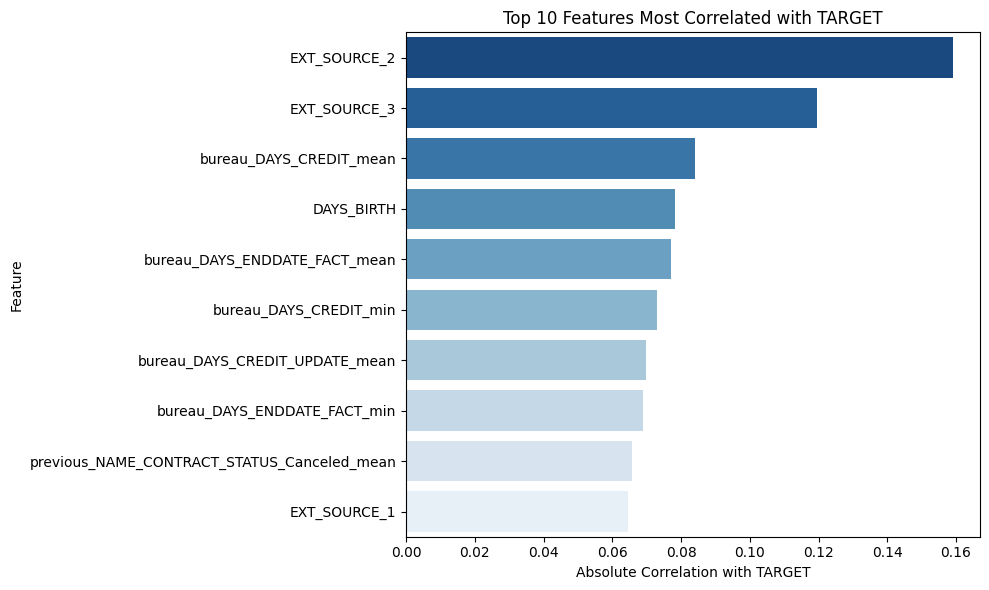

In [61]:
# Calculate correlations with the target and select the top 10 most correlated features
numeric_feature_cols = application_train.drop(columns=["SK_ID_CURR", "TARGET"], errors="ignore") \
    .select_dtypes(include=[np.number]).columns.tolist()

corr_with_target = (
    application_train[numeric_feature_cols + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
)

top10_corr = corr_with_target.abs().sort_values(ascending=False).head(10)
top10_features = top10_corr.index.tolist()

top10_corr_df = pd.DataFrame({
    "feature": top10_features,
    "corr_with_target": corr_with_target.loc[top10_features].values,
    "abs_corr": corr_with_target.loc[top10_features].abs().values
}).sort_values("abs_corr", ascending=False).reset_index(drop=True)

print("Top 10 features most correlated with TARGET:")
display(top10_corr_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_corr_df, x="abs_corr", y="feature", palette="Blues_r")
plt.title("Top 10 Features Most Correlated with TARGET")
plt.xlabel("Absolute Correlation with TARGET")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Business interpretation.** The strongest correlations with `TARGET` are dominated by external-source risk scores and historical credit behaviour. This suggests that repayment risk is not explained by a single demographic attribute; it is better captured by a combination of external credit information, income-credit relationships, and historical repayment behaviour. These insights justify the later scorecard model's focus on WOE-transformed risk features.

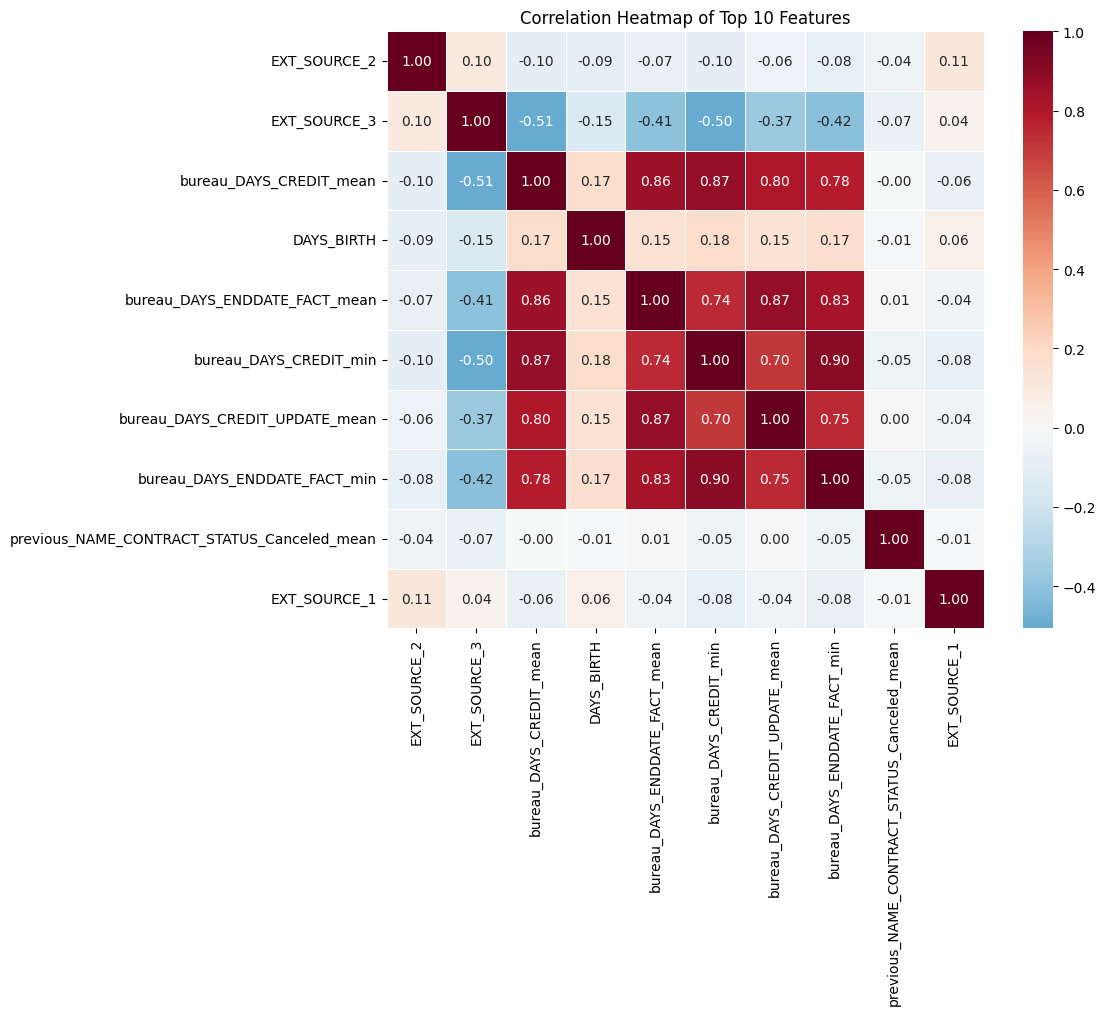

In [62]:
# Plot a heatmap of the above ten features for multivariate analysis.

heatmap_cols = top10_features
corr_matrix_top10 = application_train[heatmap_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix_top10,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Top 10 Features")
plt.tight_layout()
plt.show()

**EDA implication for modelling.** The heatmap helps identify possible multicollinearity among high-signal variables. Highly correlated predictors can make model coefficients unstable and reduce interpretability, which is why the feature-engineering pipeline later applies high-correlation filtering before the final scorecard modelling stage.

## 4.1 Bivariate analysis: EXT_SOURCE vs default risk

The correlation analysis above identifies the external credit scores `EXT_SOURCE_1/2/3` as the strongest signals related to `TARGET`. Because these are the most influential predictors in the later scorecard, it is important to show *how* they separate defaulters from non-defaulters, not only that they are correlated. The plots below overlay the distribution of each external score for repaid vs. defaulted loans.

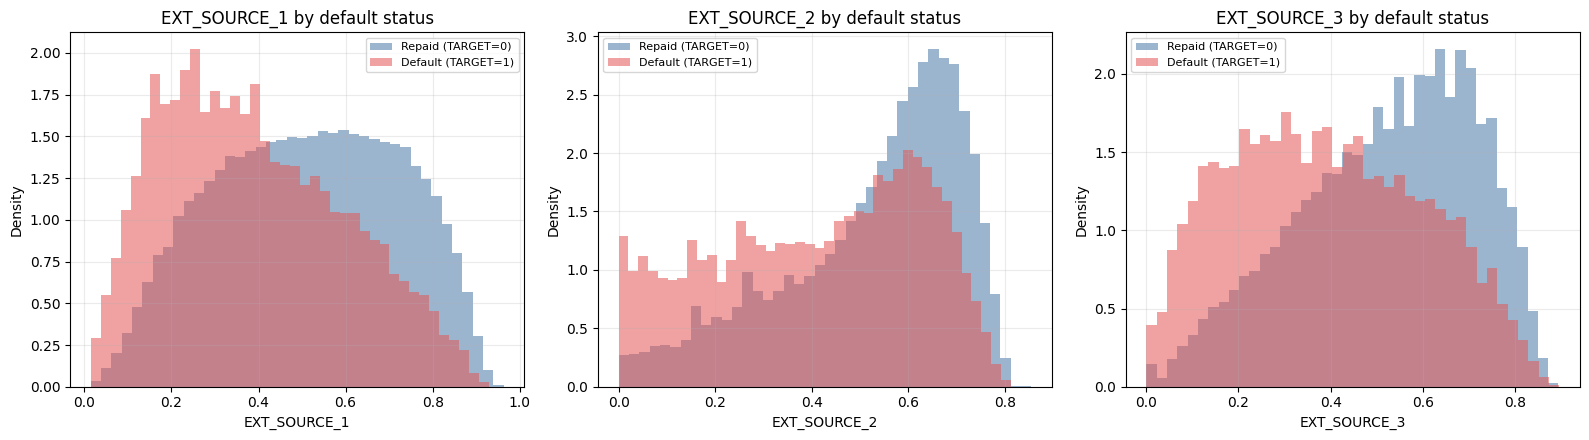

Mean external score by default status:
        EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
TARGET                                          
0             0.5115        0.5235        0.5210
1             0.3870        0.4109        0.3907


In [ ]:
# Bivariate EDA: distribution of the three external credit scores by default status.
# Read only the needed columns from the raw table so this cell is self-contained.
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_df = pd.read_csv('dataset/application_train.csv', usecols=ext_cols + ['TARGET'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ext_cols):
    for target_val, label, color in [(0, 'Repaid (TARGET=0)', '#4C78A8'), (1, 'Default (TARGET=1)', '#E45756')]:
        vals = ext_df.loc[ext_df['TARGET'] == target_val, col].dropna()
        ax.hist(vals, bins=40, density=True, alpha=0.55, label=label, color=color)
    ax.set_title(f'{col} by default status')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Mean external score by default status: lower external score -> higher default risk.
print('Mean external score by default status:')
print(ext_df.groupby('TARGET')[ext_cols].mean().round(4))

**Business interpretation.** For all three external scores, defaulted loans are shifted towards *lower* values: customers with weaker external credit scores default more often. The separation is clearest for `EXT_SOURCE_2` and `EXT_SOURCE_3`. This confirms that the external scores are not just statistically correlated with default but are genuinely discriminative, which justifies giving them a central role in the WOE scorecard built in Notebook 02.